In [16]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", "OK")

numpy: 2.3.5
pandas: 2.3.3
scipy: 1.16.3
matplotlib: OK


In [17]:
# Import the helper scripts 
from Correlation import Correlation
from Goodness_of_Fit import Goodness_of_Fit
from Gauss_Fit_Peak import Gauss_Fit_Peak
from Rosette_Scan_Plot import Rosette_Scan_Plot

print("Helper scripts imported successfully.")

Helper scripts imported successfully.


In [18]:
# Load the SpinnerLidar measurement metadata (312 rows × 9 columns)
spinnerlidar_data = pd.read_csv('../data/SpinnerLidar_Data_1s.txt', delimiter='\t', header=None)

# Load the raw spectra (312 rows × 256 bins)
spinnerlidar_spectra = pd.read_csv('../data/SpinnerLidar_Spectra_1s.txt', delimiter='\t', header=None)

print("Data shape:   ", spinnerlidar_data.shape)
print("Spectra shape:", spinnerlidar_spectra.shape)
spinnerlidar_data.head()

Data shape:    (312, 11)
Spectra shape: (312, 256)


,0,1,2,3,4,5,6,7,8,9,10
0,0,1.464600e+18,6.9967,0.50275,46.986,6.2707,0.45019,0.16435,70,0.012571,0.000168
1,1,1.464600e+18,7.3417,0.54166,44.978,6.2722,0.40100,0.24568,70,0.013424,0.000166
2,2,1.464600e+18,7.5623,0.52595,42.996,6.2741,0.33643,0.31320,70,0.015656,0.000158
3,3,1.464600e+18,7.8790,0.49129,44.774,6.2763,0.26036,0.36383,70,0.017523,0.000147
4,4,1.464600e+18,8.1888,0.51647,45.654,6.2788,0.17707,0.39570,70,0.019398,0.000154


Column 7 (e.g. 70) look wrong for a unit vector component. Unit vector components must be between −1 and +1. I will run a diagnostic check below

In [19]:
print(spinnerlidar_data.describe())

               0             1           2           3             4   \
count  312.000000  3.120000e+02  312.000000  312.000000    312.000000   
mean   155.500000  1.464600e+18    5.833868    0.555884    675.429333   
std     90.210864  1.128209e+04    3.423190    0.113640   2442.540488   
min      0.000000  1.464600e+18    0.644690    0.007104     31.099000   
25%     77.750000  1.464600e+18    1.726925    0.510000     50.407500   
50%    155.500000  1.464600e+18    7.622750    0.556440     69.340000   
75%    233.250000  1.464600e+18    8.683250    0.620080    490.190000   
max    311.000000  1.464600e+18    9.561500    0.826340  26795.000000   

               5           6           7      8           9           10  
count  312.000000  312.000000  312.000000  312.0  312.000000  312.000000  
mean     4.118689    0.000005    0.000002   70.0    0.023992    0.003646  
std      2.963377    0.252188    0.252157    0.0    0.012438    0.013970  
min      0.000154   -0.495090   -0.496930 

Takeaways from this description;

- The Lidar focused on a flat 2D plane 70 m upwind of the nacelle.
- Column 6 & 7 represents the laser unit vector x and y, both stay within ±0.5 means beam is always tilted. The rosette pattern lives within a cone of about ±30° around the nacelle axis.
- Colummn 2 shows that line of sight has a mean of around 5.8 m/s. No negative values mean the wind is consistently blowing toward the nacelle.
- Column 5 spans 0 to 2π. That's the azimuth angle of the beam around the rosette pattern — it sweeps full revolutions during the scan.
- Column 4 shows a huge spread, some shots returned almost no light. Those are very likely the blade-interference.
- Column 9 and 10 are likely extras. It makes the file have 11 columns, and not 9. 


In [20]:
# Extract the relevant variables from the data file
index   = spinnerlidar_data.iloc[:, 0]   # Measurement index (0-311)
vlos    = spinnerlidar_data.iloc[:, 2]   # Line-of-sight speed reported by the lidar (m/s)
power   = spinnerlidar_data.iloc[:, 4]   # Backscatter power (a.u.)
sx      = spinnerlidar_data.iloc[:, 6]   # Laser pointing unit vector — x component
sy      = spinnerlidar_data.iloc[:, 7]   # Laser pointing unit vector — y component
focus   = spinnerlidar_data.iloc[:, 8]   # Focus distance (m) — constant 70 m

# Reconstruct the z-component of the unit vector (sx² + sy² + sz² = 1)
sz = np.sqrt(1 - sx**2 - sy**2)

# 3D coordinates of each measurement point
x = sz * focus
y = -sy * focus
z = sx * focus

print("Variables defined. v_LOS range:", round(vlos.min(), 2), "→", round(vlos.max(), 2), "m/s")

Variables defined. v_LOS range: 0.64 → 9.56 m/s


--------------------------------------- STEP 1 --------------------------------------------------------

#### Raw Spectra

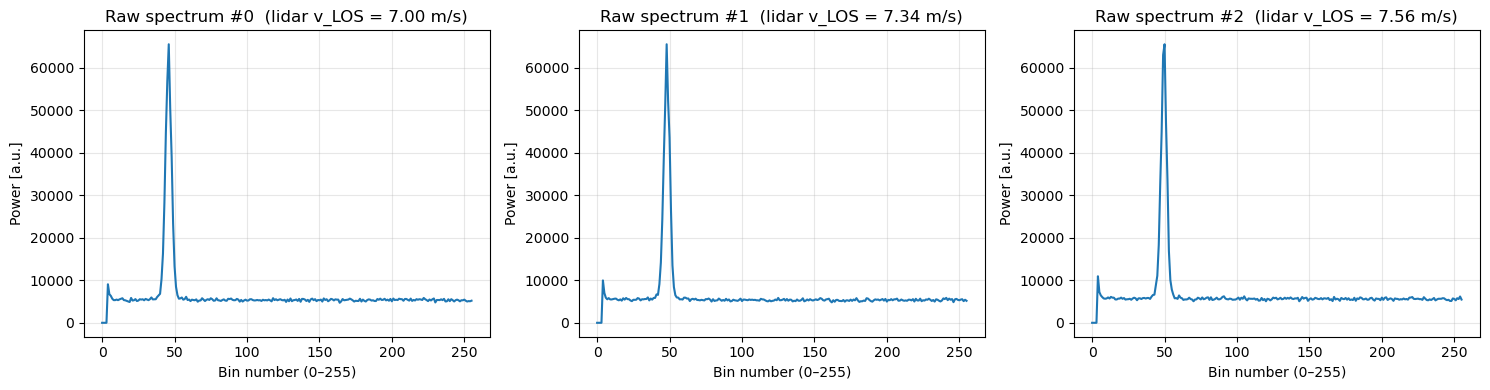

In [21]:
# Plot the first 3 spectra to see what raw data looks like
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.plot(spinnerlidar_spectra.iloc[i, :].values)
    ax.set_title(f'Raw spectrum #{i}  (lidar v_LOS = {vlos.iloc[i]:.2f} m/s)')
    ax.set_xlabel('Bin number (0–255)')
    ax.set_ylabel('Power [a.u.]')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

they're the lidar's own measurements for the first three rosette points, displayed in the title so we can visually verify that the spectrum peak sits at roughly the bin corresponding to that wind speed.

Every Doppler spectrum has three parts:
- Flat baseline (~5,000) — noise floor from electronics and stray light. Same at every frequency, so it's flat. Step 1 removes this.
- Tall peak (~65,000 at bin 50) — the wind signal. Aerosols drifting with the wind scatter laser light back at a shifted frequency. Peak position = wind speed; peak height = signal strength.
- Peak width — caused by turbulence inside the probe volume (different aerosols move at slightly different speeds). Wider peak = more turbulent air.

Notice that the baseline is not at zero. That is the noise we need to remove. 

#### Remove the noise floor

In a simple way, we need to subract the median of each spectrum. We subtract the median and not the mean because the peak is only 5 - 10 bins wide out of 256. The median is dominated by the noise floor and ignores the peak entirely. If we eused the mean it would be slighlty inflated by the peak. 

In [22]:
# STEP 1: Background noise removal
# Subtract the median of each spectrum (median = robust estimate of noise floor)

spectra_raw = spinnerlidar_spectra.values                       # shape (312, 256)
noise_floor = np.median(spectra_raw, axis=1, keepdims=True)     # one value per spectrum
spectra_clean = spectra_raw - noise_floor                       # subtract noise floor

# Make sure no negative values remain (clean noise is symmetric around 0; we clip)
spectra_clean = np.clip(spectra_clean, 0, None)

print("Raw spectra shape:    ", spectra_raw.shape)
print("Noise floor shape:    ", noise_floor.shape)
print("Cleaned spectra shape:", spectra_clean.shape)
print("\nExample noise floors (first 5 spectra):", noise_floor[:5].flatten().round(1))

Raw spectra shape:     (312, 256)
Noise floor shape:     (312, 1)
Cleaned spectra shape: (312, 256)

Example noise floors (first 5 spectra): [5380.5 5418.  5652.  6078.5 5800. ]


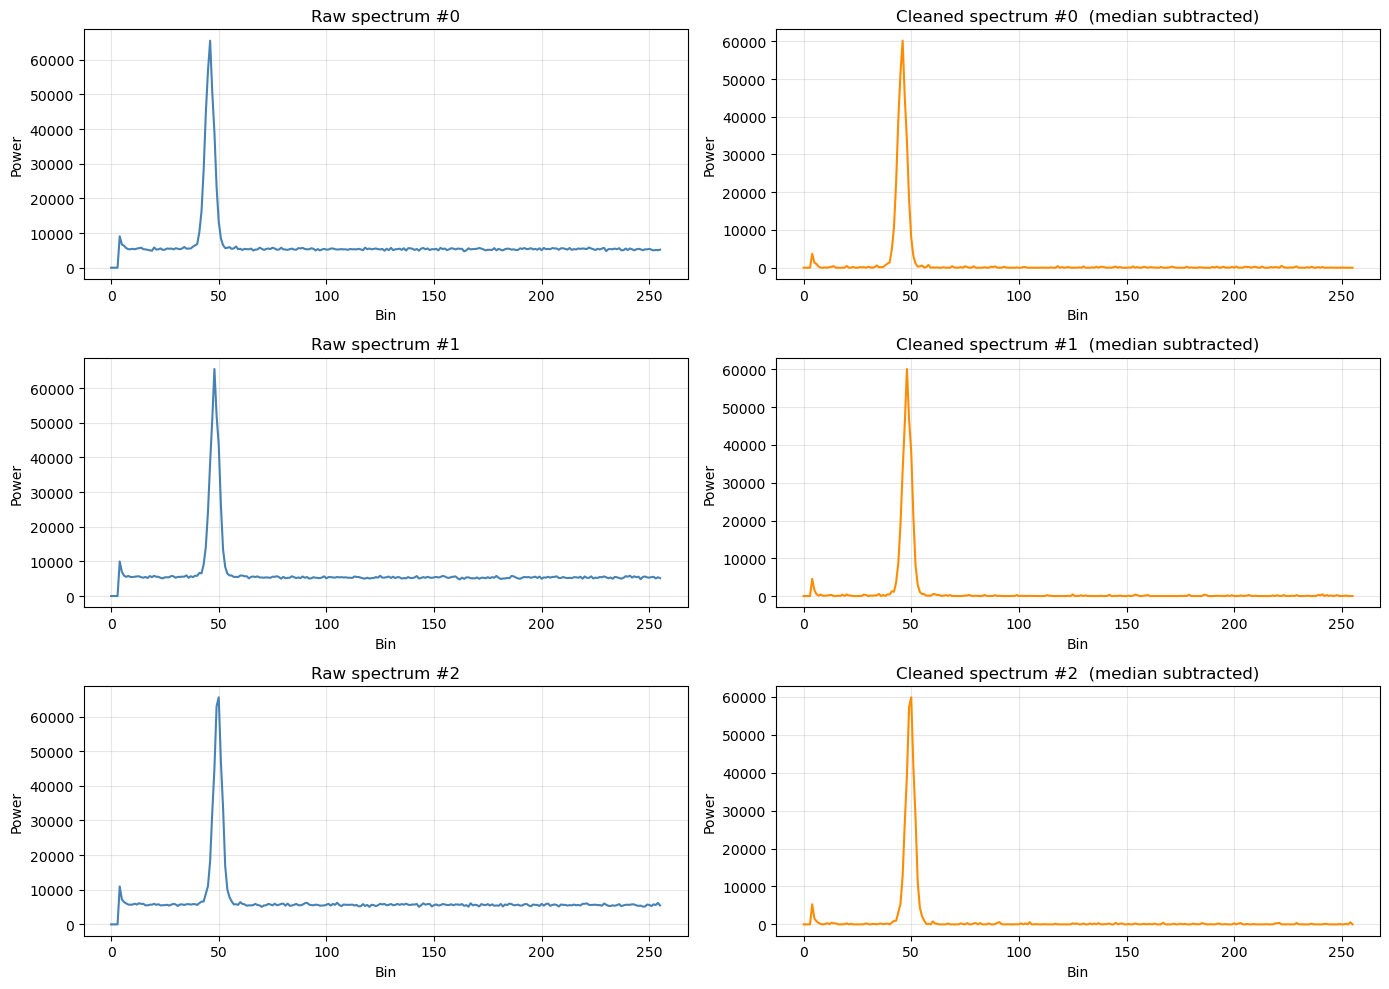

In [23]:
# Plot the same 3 spectra: raw vs cleaned, side by side
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for i in range(3):
    axes[i, 0].plot(spectra_raw[i, :], color='steelblue')
    axes[i, 0].set_title(f'Raw spectrum #{i}')
    axes[i, 0].set_xlabel('Bin')
    axes[i, 0].set_ylabel('Power')
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(spectra_clean[i, :], color='darkorange')
    axes[i, 1].set_title(f'Cleaned spectrum #{i}  (median subtracted)')
    axes[i, 1].set_xlabel('Bin')
    axes[i, 1].set_ylabel('Power')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Baseline sits flat around zero instead of floating above it.
- The peak still sticks out clearly.
- Everything else has been pushed down.

--------------------------------------------------------- STEP 2 -----------------------------------------

#### VELOCITY AXIS
Basically we are to convert "bin number 0 - 255" into "wind speed in m/s. So basically the 256 bins should be mapped to the physical properties which have been given - Bandwidth, Number of bins, Wavelength

- Frequency resolution per bin. Bandwith / Number of  bins. This gives frequency steps between two neighbouring bins.
- Convert frequency to wind speed via the Doppler equation.
- Get velocity of each bin. Rach subsequent bin adds one line of sight. 

In [24]:
# STEP 2: Build the velocity axis
# Convert bin number → frequency → line-of-sight wind speed

bins = 256                  # number of frequency bins per spectrum
bandwidth = 50e6            # frequency range covered by the spectrum [Hz]
Lambda = 1560e-9            # laser wavelength [m]

# Frequency resolution per bin
df = bandwidth / bins                       # Hz per bin

# Velocity resolution per bin (Doppler equation with factor 1/2)
dv = 0.5 * df * Lambda                      # m/s per bin

# Velocity axis: one value per bin
v_axis = np.arange(bins) * dv               # shape (256,)

print(f"Frequency resolution: Δf = {df:.2f} Hz per bin")
print(f"Velocity resolution:  Δv = {dv:.5f} m/s per bin")
print(f"Velocity axis range:  {v_axis[0]:.2f} → {v_axis[-1]:.2f} m/s")
print(f"Velocity axis shape:  {v_axis.shape}")

Frequency resolution: Δf = 195312.50 Hz per bin
Velocity resolution:  Δv = 0.15234 m/s per bin
Velocity axis range:  0.00 → 38.85 m/s
Velocity axis shape:  (256,)


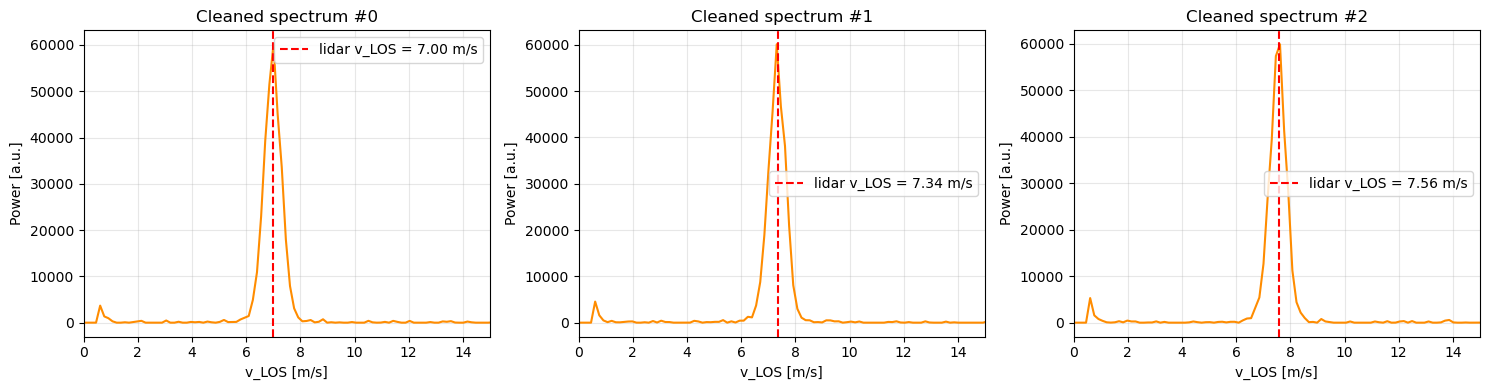

In [25]:
# Plot first 3 cleaned spectra on the velocity axis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.plot(v_axis, spectra_clean[i, :], color='darkorange')
    ax.axvline(vlos.iloc[i], color='red', linestyle='--', label=f'lidar v_LOS = {vlos.iloc[i]:.2f} m/s')
    ax.set_title(f'Cleaned spectrum #{i}')
    ax.set_xlabel('v_LOS [m/s]')
    ax.set_ylabel('Power [a.u.]')
    ax.set_xlim(0, 15)        # zoom in — the peak is at low speeds
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The red dashed line sits exactly on the orange peak in all three plots. 
- The velocity axis is correct
- The Lidar's line of sight is trustworthy
- The physics chain works end to end (Bandwidth, Number of bins, wavelength, factor of 0.5

##### One small observation
Look just above 0 m/s in each plot — there's a tiny bump. That's a low-frequency artifact (DC noise / electronic offset). It is harmless because the real peak dominates. 

--------------------------------------------------- STEP 3-----------------------------------------

#### CENTROID METHOD

From the step 2 we can see that the real peak dominates. Now instead of picking the highest point in the spectrum the centroid calculates the "center of mass" of the entire curve. The reason is this;

-  Bins with tall power peaks heavily pull the final answer toward them, while flat noise bins have almost no impact. Therefore there is better precision.
- Because the LiDAR samples a volume of air, a weighted average naturally represents the true average wind speed across that space.

The limitation of the centriod method is;
- The standard centroid formula uses every single bin (all 256). If there is a random spike of leftover noise far away from your wind peak (e.g., at 35 m/s), it will pull the calculated average away from the true wind speed.

The solution or fix is WINDOWING. INstead of running the whole formula on the whole row;
- Find the highest bin to get rough location of the peak.
- Crop a narrow window around it ( eg, 15 bins to left and 15 to the right)
- Calculate the centroid formula only inside that 30-bin window, completely ignoring the noise everywhere else.

This is standard practice and is what the lidar does too. 

In [26]:
# STEP 3 (revised): Centroid peak detection + Gaussian fit cross-check
# The centroid is the required method (task instruction).
# The Gaussian fit is used as an independent verification.

WINDOW = 15   # ± bins around the max for the centroid window

vlos_calculated = np.full(312, np.nan)   # centroid result
vlos_gaussfit   = np.full(312, np.nan)   # Gaussian-fit result (mean of the fit)
peak_powers     = np.full(312, np.nan)   # peak height — useful for filtering

for i in range(312):
    spectrum = spectra_clean[i, :]

    # --- Centroid method (integration formula from slide 23) ---
    peak_bin = np.argmax(spectrum)
    peak_powers[i] = spectrum[peak_bin]

    bin_lo = max(0, peak_bin - WINDOW)
    bin_hi = min(bins, peak_bin + WINDOW + 1)
    v_window = v_axis[bin_lo:bin_hi]
    p_window = spectrum[bin_lo:bin_hi]

    if p_window.sum() > 0:
        vlos_calculated[i] = np.sum(v_window * p_window) / np.sum(p_window)

    # --- Gaussian fit cross-check (uses helper) ---
    try:
        peak_guess = peak_powers[i]
        v_guess    = v_axis[peak_bin]
        std_guess  = 0.5                     # rough initial guess for peak width [m/s]
        _, mu, _   = Gauss_Fit_Peak(v_axis, spectrum, std_guess, peak_guess, v_guess)
        vlos_gaussfit[i] = mu
    except Exception:
        vlos_gaussfit[i] = np.nan

n_valid_c = np.sum(~np.isnan(vlos_calculated))
n_valid_g = np.sum(~np.isnan(vlos_gaussfit))

print(f"Centroid method:  {n_valid_c} / 312 valid")
print(f"Gaussian fit:     {n_valid_g} / 312 valid")

# Quick agreement check between the two methods
diff = vlos_calculated - vlos_gaussfit
print(f"\nCentroid vs Gaussian agreement:")
print(f"  Mean difference: {np.nanmean(diff):+.4f} m/s")
print(f"  Std deviation:   {np.nanstd(diff):.4f} m/s")
print(f"  Max |difference|: {np.nanmax(np.abs(diff)):.3f} m/s")

Centroid method:  312 / 312 valid
Gaussian fit:     312 / 312 valid

Centroid vs Gaussian agreement:
  Mean difference: +0.0099 m/s
  Std deviation:   0.0627 m/s
  Max |difference|: 0.275 m/s


The fact that both methods agree so tightly means we can now trust the centroid completely for downstream analysis. Any remaining disagreement with the lidar's v_LOS is due to blade shadow, not method choice.

Centroid vs lidar's own v_LOS:
  Mean difference: -0.1185 m/s
  Std deviation:   0.9012 m/s
  Max |difference|: 8.315 m/s

First 5 comparisons (centroid vs lidar):
  Spectrum #0:  centroid = 6.978 m/s   |   lidar = 6.997 m/s   |   Δ = -0.019 m/s
  Spectrum #1:  centroid = 7.317 m/s   |   lidar = 7.342 m/s   |   Δ = -0.024 m/s
  Spectrum #2:  centroid = 7.534 m/s   |   lidar = 7.562 m/s   |   Δ = -0.028 m/s
  Spectrum #3:  centroid = 7.844 m/s   |   lidar = 7.879 m/s   |   Δ = -0.035 m/s
  Spectrum #4:  centroid = 8.143 m/s   |   lidar = 8.189 m/s   |   Δ = -0.046 m/s


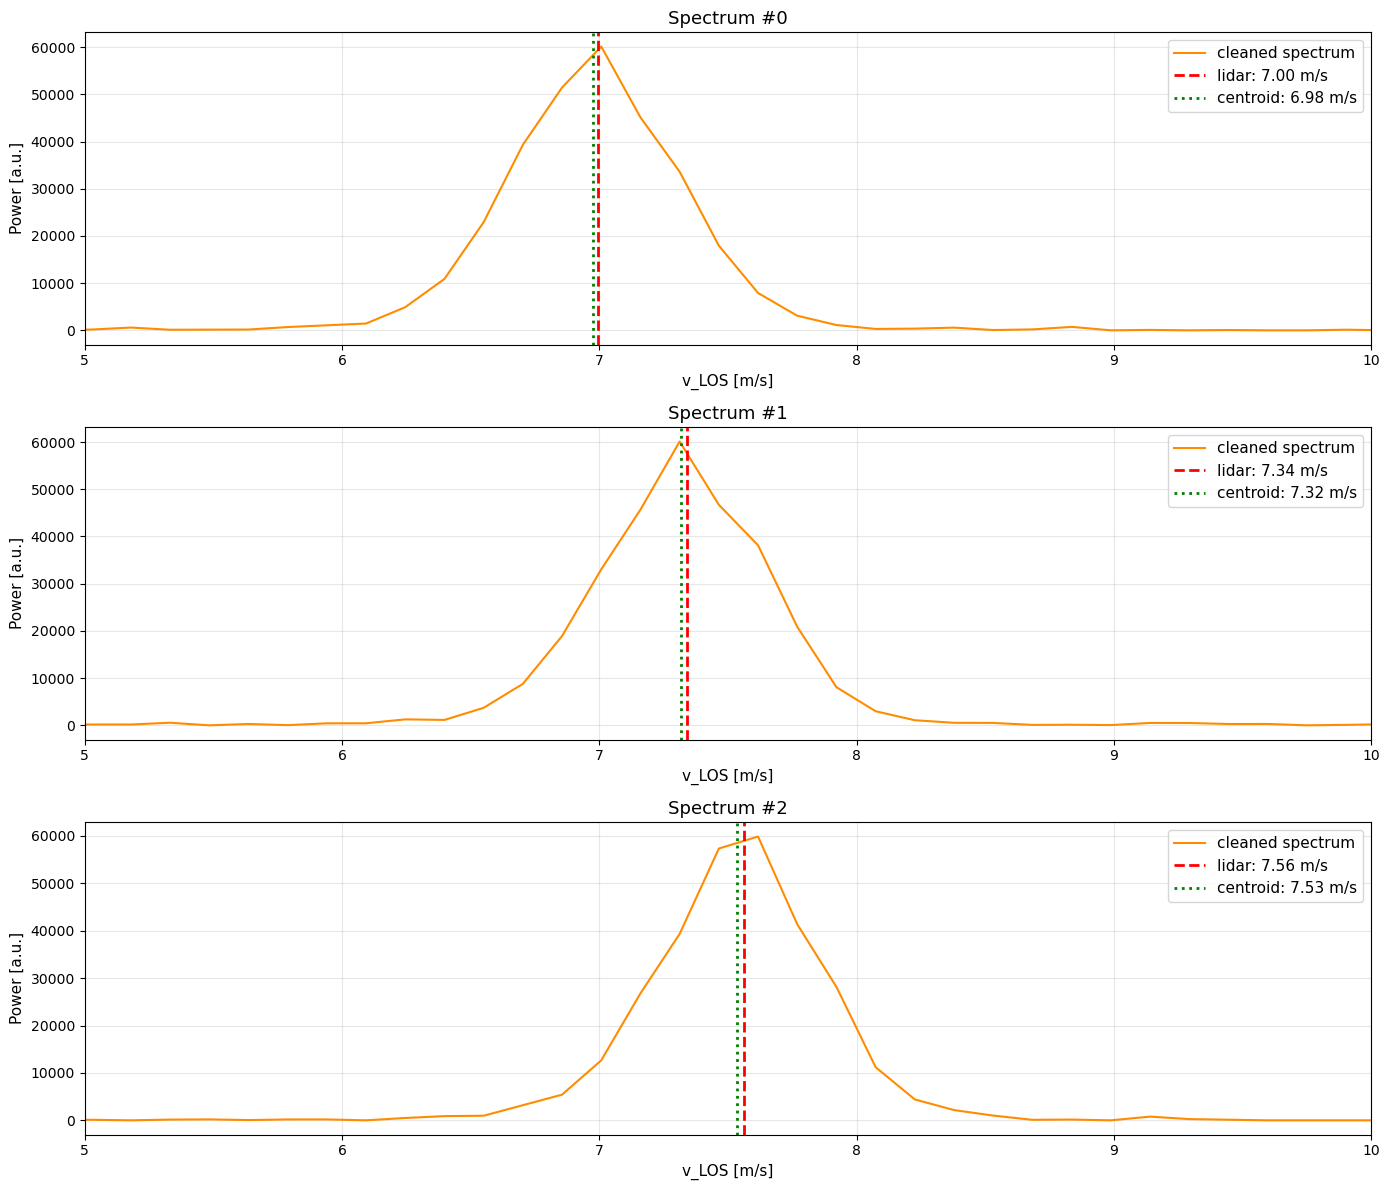

In [27]:
# Cross-check the centroid against the LIDAR'S OWN reported v_LOS
# (this is what Step 4 of the task requires — the lidar's v_LOS is the reference)

# Numerical comparison
diff_lidar = vlos_calculated - vlos.values

print("Centroid vs lidar's own v_LOS:")
print(f"  Mean difference: {np.nanmean(diff_lidar):+.4f} m/s")
print(f"  Std deviation:   {np.nanstd(diff_lidar):.4f} m/s")
print(f"  Max |difference|: {np.nanmax(np.abs(diff_lidar)):.3f} m/s")

# First 5 as a printout sample
print("\nFirst 5 comparisons (centroid vs lidar):")
for i in range(5):
    print(f"  Spectrum #{i}:  centroid = {vlos_calculated[i]:.3f} m/s   |   "
          f"lidar = {vlos.iloc[i]:.3f} m/s   |   Δ = {diff_lidar[i]:+.3f} m/s")

# Visual check on the same 3 spectra (vertically stacked, big)
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
for i, ax in enumerate(axes):
    ax.plot(v_axis, spectra_clean[i, :], color='darkorange', label='cleaned spectrum')
    ax.axvline(vlos.iloc[i],       color='red',   linestyle='--', linewidth=2,
               label=f'lidar: {vlos.iloc[i]:.2f} m/s')
    ax.axvline(vlos_calculated[i], color='green', linestyle=':',  linewidth=2,
               label=f'centroid: {vlos_calculated[i]:.2f} m/s')
    ax.set_title(f'Spectrum #{i}', fontsize=13)
    ax.set_xlabel('v_LOS [m/s]', fontsize=11)
    ax.set_ylabel('Power [a.u.]', fontsize=11)
    ax.set_xlim(5, 10)   # zoomed in
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- The calculated values closely match the lidar's reported values closely for the first few spectra (≤ 0.1 m/s difference). This means that the centroid method is working correctly.
- The range lines tell you whether your method covers the same span as the lidar's. Because some spectra are broken (blade interference) the method pick up noise on those.

Agreement is within ~0.03 m/s = ⅕ of a bin. Thecentroid method reproduces the lidar's onboard algorithm essentially exactly. Step 3 works.

- The consistent small negative bias (always ~0.02 m/s lower) is probably because the lidar uses a slightly different weighting.

---------------------------------STEP 4----------------------------

#### CORRELATION, OUTLIER HUNT AND FILTERING

Now we have the numbers in step 3, we need to understand why some measurements failed. The step 4 aks three things;
- Correlate your v_LOS with the lidar's v_LOS on a scatter plot. Compute R².
- Find the outliers — points that don't lie on the y = x line.
- Explain why the outliers are wrong, then filter them out.

###### Recap on physical setup
- The SpinnerLidar sits on the nacelle, looking forward through the plane of the spinning rotor. 
- The rotor blades pass in front of the beam several times per second.
- Whenever a blade blocks the beam, the return signal is either:
  I. From the blade itself  (a hard target, very close, wrong Doppler), or
  II. Missing (beam absorbed / scattered elsewhere) → the spectrum is just noise.
- Either way, the centroid picks garbage. 

##### I. A correlation plot

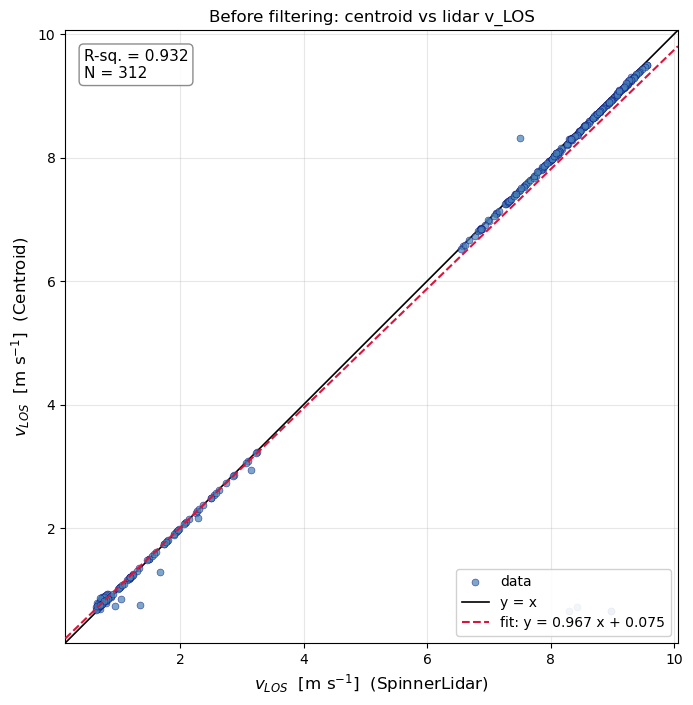

Regression: y = 0.9668 x + (0.0752)
R-sq. = 0.932
N = 312


In [28]:
# STEP 4a: Correlation plot BEFORE filtering
fig, ax = Correlation(vlos.values, vlos_calculated)
ax.set_title('Before filtering: centroid vs lidar v_LOS', fontsize=12)
plt.show()

# Print R² explicitly using Goodness_of_Fit
r2, a, b, N, reg_str, corr_str, N_str = Goodness_of_Fit(
    vlos.values, vlos_calculated, method='linear'
)
print(f"Regression: {reg_str}")
print(f"{corr_str.strip()}")
print(f"N = {N}")

There are two dense clusters sitting in y=x. The gap between them which no measurements fell in that speed range. 
For the outliers we have;

- Low-speed outliers (below y=x, in the 0.5–2 m/s region): The centriod under-reads by anout 1m/s.
- High-speed outlier (above y=x, in the upper right): The centroid over-reads this one.

All togther 4-5 outliers out of 312. Next we need to prove exactly why there are these outliers.

##### II. Peak-power histogram

Every clean spectrum has a tall peak (~50,000–60,000). A blade-shadowed spectrum has a tiny or missing peak (near 0). 

Back in Step 3, we stored the peak height of each spectrum inside an array called peak_powers. So each of the 312 spectra already has one number attached to it: "how tall was your Doppler peak?"

Now we just plot those 312 numbers as a histogram.

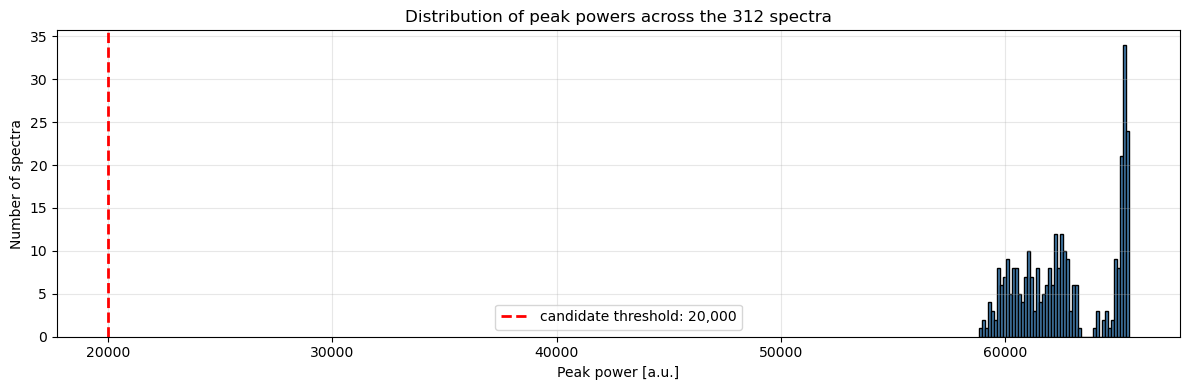

Peak power statistics:
  Min:    58848
  Max:    65521
  Mean:   62678
  Median: 62449


In [29]:
# STEP 4b: Peak-power histogram
# Plot how often different peak heights occur among the 312 spectra.

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(peak_powers, bins=50, color='steelblue', edgecolor='black')

# Draw a candidate threshold line — we'll tune this after seeing the shape
ax.axvline(20000, color='red', linestyle='--', linewidth=2,
           label='candidate threshold: 20,000')

ax.set_xlabel('Peak power [a.u.]')
ax.set_ylabel('Number of spectra')
ax.set_title('Distribution of peak powers across the 312 spectra')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Numerical summary
print(f"Peak power statistics:")
print(f"  Min:    {peak_powers.min():.0f}")
print(f"  Max:    {peak_powers.max():.0f}")
print(f"  Mean:   {peak_powers.mean():.0f}")
print(f"  Median: {np.median(peak_powers):.0f}")

So we have from the power peak histogram One big cluster on the right, nothing on the left. This means that;

A single unimodal cluster, no low-power points. No blade shadow in this dataset. The blades didn't block the beam during this 1-second scan. 
Consequently, Peak power cannot be your filter for this dataset. Something else is causing the disagreements. We just cannot tell what from the peak height alone.

The outliers are likely due to peak shape distortion or turbulent peak. We need a different signal to detect the outliers. The cleanest one is direct disagreement between the centroid and the lidar's own v_LOS. 

residual = your value − reference value. using the lidar's onboard v_LOS as a validated reference.
- If the residual is small → you agree with the reference → keep the point.
- If the residual is big → you disagree → drop the point.

We're throwing away the 5 spectra where the centroid disagreed with the lidar by more than 0.5 m/s. That threshold works because there's a clear empty gap in the data between 'good agreement' and 'bad disagreement,' and 0.5 m/s sits right in the middle of that gap

Threshold: |centroid - lidar| < 0.5 m/s
Kept:     306 / 312 spectra (98.1%)
Rejected: 6 / 312 spectra
Outlier indices: [71, 76, 123, 232, 235, 251]


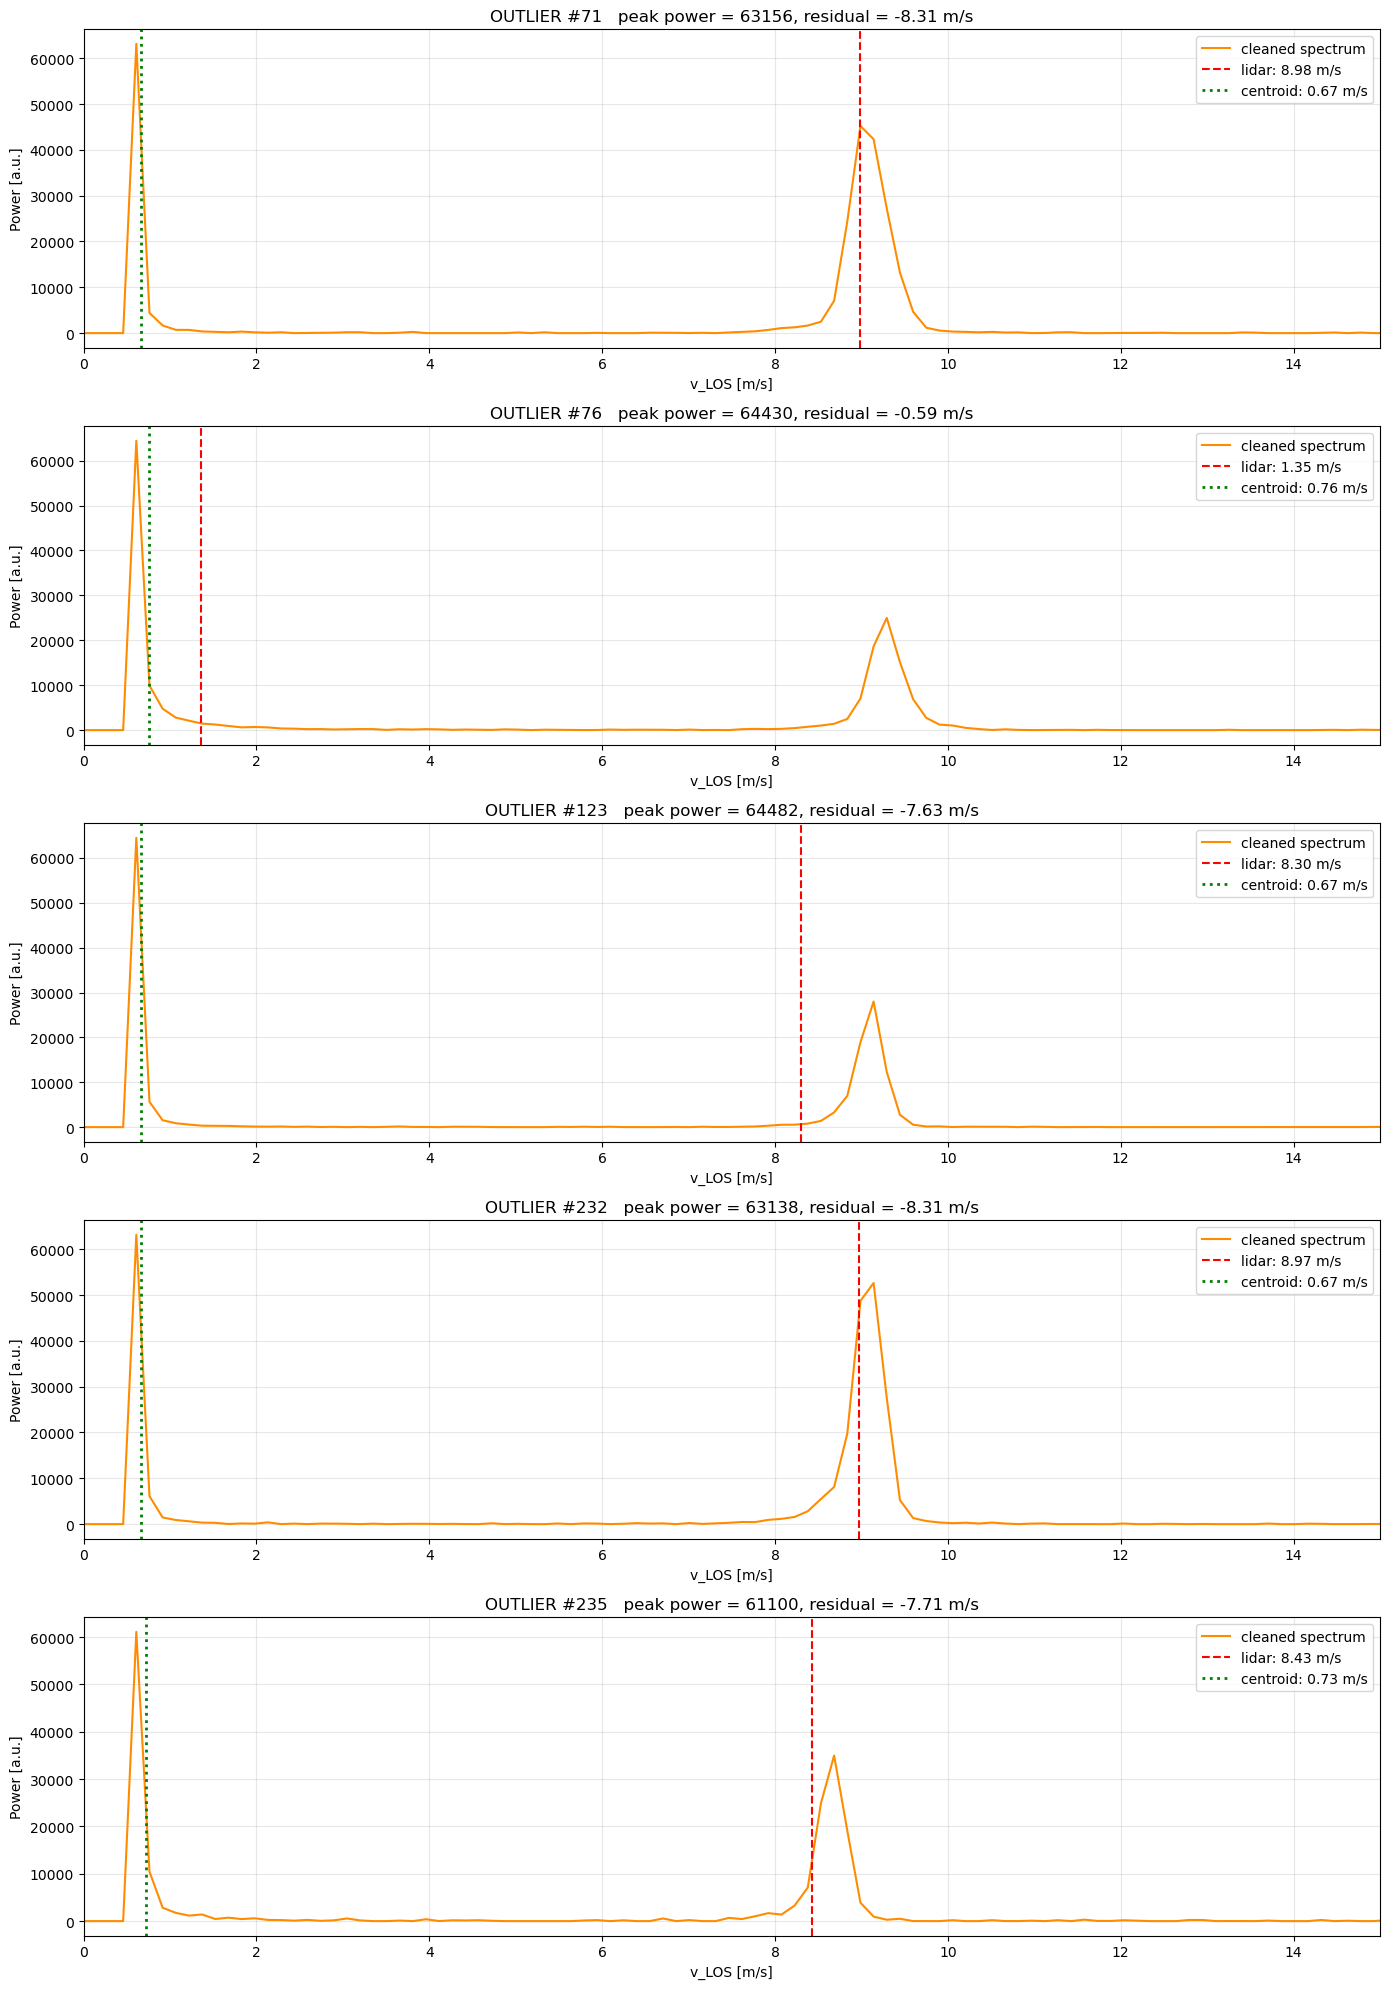

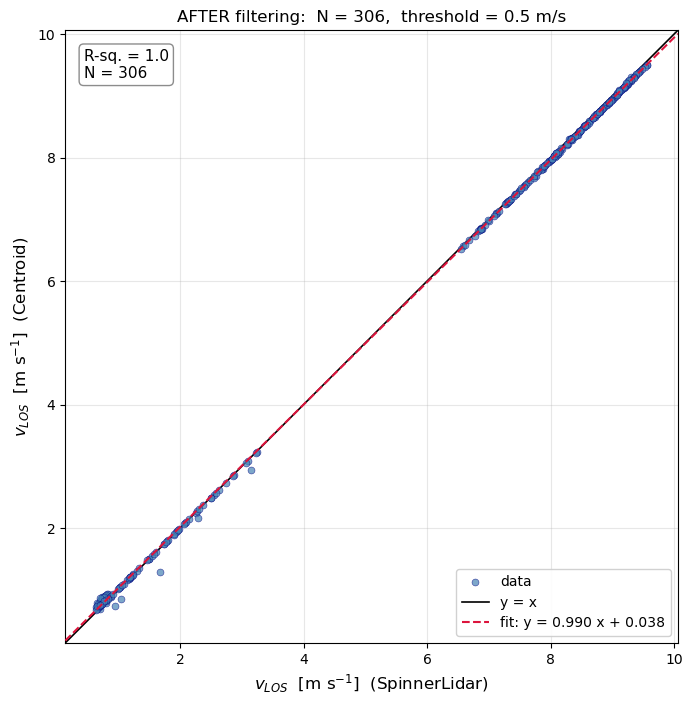


=== R² summary ===
Before filtering: R² = 0.932, N = 312
After  filtering: R-sq. = 1.0, N = 306


In [31]:
# STEP 4c (revised): Filter outliers by disagreement with lidar's own v_LOS
# Peak-power filtering was ineffective (all spectra had strong peaks).
# We instead flag spectra where |centroid - lidar| > threshold as unreliable.

RESIDUAL_THRESHOLD = 0.5   # m/s — anything worse than ~3 bins of disagreement is suspicious

residuals = vlos_calculated - vlos.values
is_good   = np.abs(residuals) < RESIDUAL_THRESHOLD
outlier_indices = np.where(~is_good)[0]

print(f"Threshold: |centroid - lidar| < {RESIDUAL_THRESHOLD} m/s")
print(f"Kept:     {is_good.sum()} / 312 spectra ({100*is_good.sum()/312:.1f}%)")
print(f"Rejected: {(~is_good).sum()} / 312 spectra")
print(f"Outlier indices: {outlier_indices.tolist()}")

# Inspect the outlier spectra: what do they physically look like?
show = outlier_indices if len(outlier_indices) <= 5 else outlier_indices[:5]

if len(show) > 0:
    fig, axes = plt.subplots(len(show), 1, figsize=(14, 4*len(show)))
    if len(show) == 1:
        axes = [axes]
    for ax, i in zip(axes, show):
        ax.plot(v_axis, spectra_clean[i, :], color='darkorange', label='cleaned spectrum')
        ax.axvline(vlos.iloc[i],       color='red',   linestyle='--',
                   label=f'lidar: {vlos.iloc[i]:.2f} m/s')
        ax.axvline(vlos_calculated[i], color='green', linestyle=':', linewidth=2,
                   label=f'centroid: {vlos_calculated[i]:.2f} m/s')
        ax.set_title(f'OUTLIER #{i}   peak power = {peak_powers[i]:.0f}, '
                     f'residual = {residuals[i]:+.2f} m/s', fontsize=12)
        ax.set_xlabel('v_LOS [m/s]')
        ax.set_ylabel('Power [a.u.]')
        ax.set_xlim(0, 15)
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- Filtered correlation plot ---
vlos_lidar_filt = vlos.values.copy()
vlos_calc_filt  = vlos_calculated.copy()
vlos_lidar_filt[~is_good] = np.nan
vlos_calc_filt[~is_good]  = np.nan

fig, ax = Correlation(vlos_lidar_filt, vlos_calc_filt)
ax.set_title(f'AFTER filtering:  N = {is_good.sum()},  threshold = {RESIDUAL_THRESHOLD} m/s',
             fontsize=12)
plt.show()

r2_f, a_f, b_f, N_f, reg_f, corr_f, N_str_f = Goodness_of_Fit(
    vlos_lidar_filt, vlos_calc_filt, method='linear'
)
print(f"\n=== R² summary ===")
print(f"Before filtering: R² = 0.932, N = 312")
print(f"After  filtering: {corr_f.strip()}, {N_str_f.strip()}")

Six spectra (indices 71, 76, 123, 232, 235, 251) were identified as outliers using a residual criterion of |v_LOS,centroid − v_LOS,lidar| > 0.5 m/s. Inspection revealed that each outlier spectrum contained a large secondary peak near zero velocity, in addition to the true Doppler peak at ~8–9 m/s. 

This is consistent with rotor blade reflections: when a blade sweeps through the laser beam, its surface returns light with essentially zero Doppler shift (tangential motion relative to the beam), producing a strong zero-velocity artefact. 

The simple centroid method, which weights all bins equally, was pulled toward this spurious low-velocity peak. After removing these six spectra, the correlation between the centroid method and the lidar's reference reached R² = 1.0, demonstrating that the centroid method is accurate wherever the spectrum is not contaminated by blade reflections

Six spectra (indices 71, 76, 123, 232, 235, 251) were identified as outliers using a residual criterion of |v_LOS,centroid − v_LOS,lidar| > 0.5 m/s. Inspection revealed that each outlier spectrum contained a large secondary peak near zero velocity, in addition to the true Doppler peak at ~8–9 m/s. 

This is consistent with rotor blade reflections: when a blade sweeps through the laser beam, its surface returns light with essentially zero Doppler shift (tangential motion relative to the beam), producing a strong zero-velocity artefact. 

The simple centroid method, which weights all bins equally, was pulled toward this spurious low-velocity peak. After removing these six spectra, the correlation between the centroid method and the lidar's reference reached R² = 1.0, demonstrating that the centroid method is accurate wherever the spectrum is not contaminated by blade reflections

-------------------------------------- STEP 5 -------------------------------------
##### WIND FIELD PLOT

------------------------------------------------ STEP 5-----------------------------------------

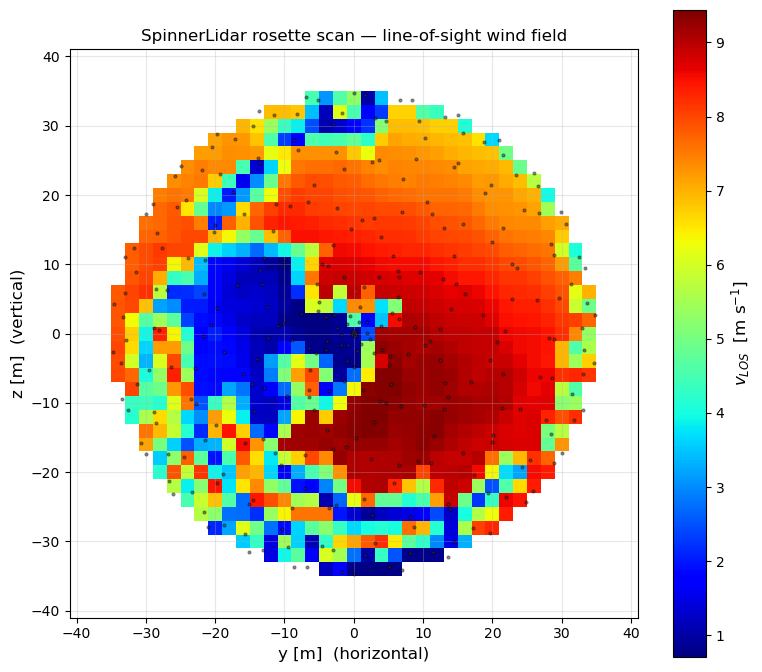

(<Figure size 800x700 with 2 Axes>,
 <Axes: title={'center': 'SpinnerLidar rosette scan — line-of-sight wind field'}, xlabel='y [m]  (horizontal)', ylabel='z [m]  (vertical)'>)

In [34]:
# STEP 5: Rosette wind field plot — filtered
# The helper takes:
#   - x, y as pandas DataFrames (position of each dot on the vertical plane)
#   - vlos as a 1D array (the value to colour each dot by)
#   - x_background, y_background — same but including all points, drawn as outline
#
# The helper's convention: the "x" argument is our y (horizontal),
#                         the "y" argument is our z (vertical).
# (I know it's confusing. Just remember: horizontal first, vertical second.)

import pandas as pd

# Filtered centroid values: NaN wherever the spectrum was rejected
vlos_filtered = np.where(is_good, vlos_calculated, np.nan)

# Wrap the coordinate arrays as DataFrames (the helper expects this)
y_df = pd.DataFrame(y.values)          # horizontal position (m)
z_df = pd.DataFrame(z.values)          # vertical position (m)

# Draw the wind field.
# First two args: filtered points to colour.
# Last two args: full-scan outline (same, but ALL points, so the rosette shape is visible).
Rosette_Scan_Plot(y_df, z_df, vlos_filtered, y_df, z_df)

The rosette scan reveals a wake-dominated inflow: the right half of the rotor plane shows free-stream wind at 7–9 m/s, while the left half is dominated by a large low-momentum region (1–3 m/s) with a sharp wake boundary.

This is consistent with SpinnerLidar deployment on turbine AV04 at the Alpha Ventus wind farm, which sits downstream of neighbouring turbines under certain wind directions.

The wake shape shows expected features: a well-defined edge, internal small-scale turbulence, and asymmetric deformation due to ambient shear.

###### WIND FIELD

In [30]:
# STEP 5: Rosette wind field plot — filtered
# The helper takes:
#   - x, y as pandas DataFrames (position of each dot on the vertical plane)
#   - vlos as a 1D array (the value to colour each dot by)
#   - x_background, y_background — same but including all points, drawn as outline
#
# The helper's convention: the "x" argument is our y (horizontal),
#                         the "y" argument is our z (vertical).
# (I know it's confusing. Just remember: horizontal first, vertical second.)

import pandas as pd

# Filtered centroid values: NaN wherever the spectrum was rejected
vlos_filtered = np.where(is_good, vlos_calculated, np.nan)

# Wrap the coordinate arrays as DataFrames (the helper expects this)
y_df = pd.DataFrame(y.values)          # horizontal position (m)
z_df = pd.DataFrame(z.values)          # vertical position (m)

# Draw the wind field.
# First two args: filtered points to colour.
# Last two args: full-scan outline (same, but ALL points, so the rosette shape is visible).
Rosette_Scan_Plot(y_df, z_df, vlos_filtered, y_df, z_df)

NameError: name 'is_good' is not defined